## Clustering for customers

In [ ]:
# Data manipulation and linear algebra
import pandas as pd
import numpy as np

# Data visualization 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Data Pre-processing 
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

# Hierarchical clustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

# Python display
from IPython.core.display import display, HTML

import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import data 
df = pd.read_csv('Mall_Customers.csv')

#### Viewing the data set

In [53]:
# View data head 
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [54]:
# check column types and lenghth
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [55]:
# Summary table of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


#### Data pre-processing

In [56]:
# Check for missing data 
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [57]:
# Drop tthe index 
df.drop('CustomerID', axis=1, inplace=True)

In [58]:
# check the df 
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Data visualization

In [59]:
# Bin the data to improve the plot
# SNS count plot does not bin automatically
df_plot = df.copy()
age_bins = [18, 26, 36, 46, 56, 66, 100]
df_plot['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

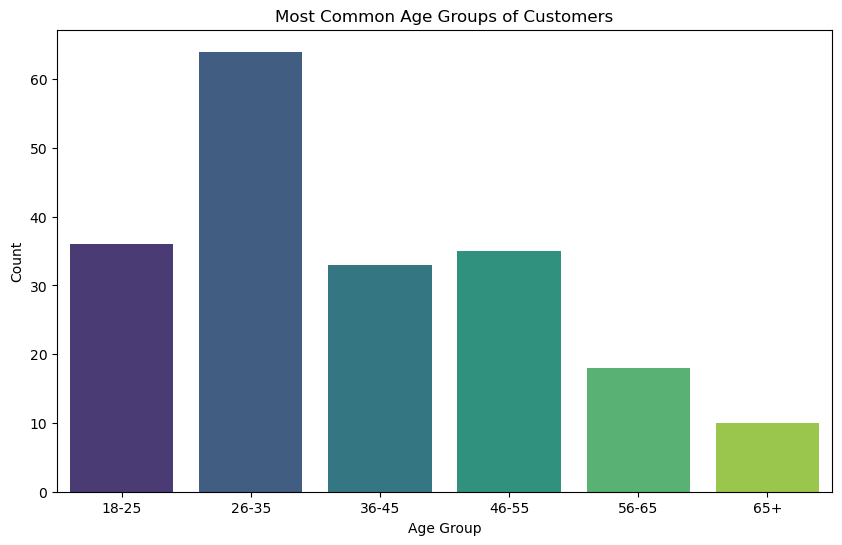

In [60]:
# Disturbution of customers by age group 

# For figure size
plt.figure(figsize=(10, 6))
# Plot
sns.countplot(data=df_plot, x='Age Group', palette='viridis')
# Labeling the plot
plt.title('Most Common Age Groups of Customers')
plt.xlabel('Age Group')
plt.ylabel('Count')
# Show
plt.show()

#### Spending distribution

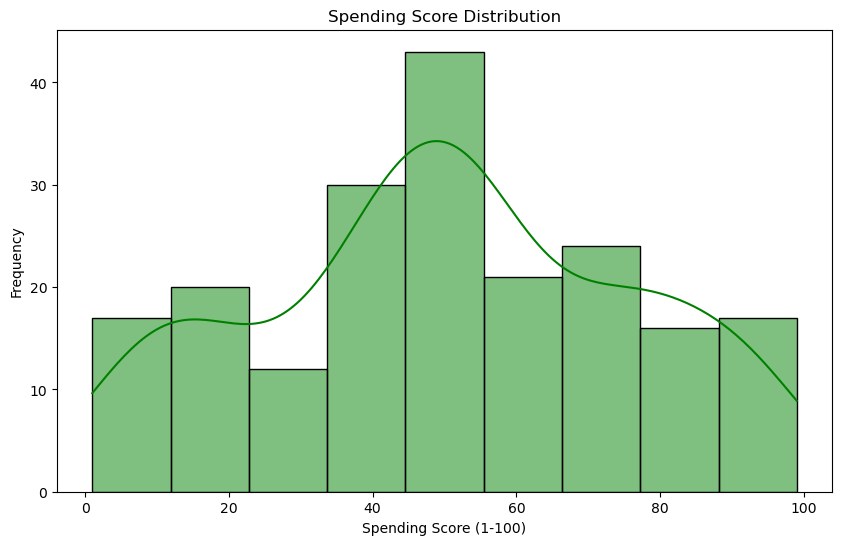

In [61]:
# Figure size
plt.figure(figsize=(10, 6))

# Define plot
sns.histplot(df['Spending Score (1-100)'], kde=True, color='green')

# Add details to the plot
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')

# Show
plt.show()

#### Spending Score Distribution by Spending Range

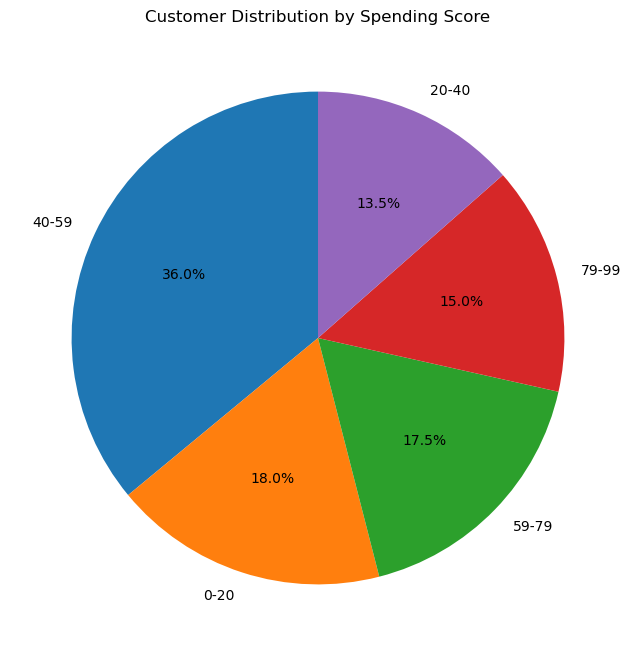

In [62]:

# Define the data to use
spending_counts = df['Spending Score (1-100)'].value_counts(bins=5)
# Label the data
spending_labels = [f'{int(bin.left)}-{int(bin.right)}' for bin in spending_counts.index]
# figure size
plt.figure(figsize=(8, 8))
# Define plot type
plt.pie(spending_counts, labels=spending_labels, autopct='%1.1f%%', startangle=90)
# Plot details 
plt.title('Customer Distribution by Spending Score')
# Show plot
plt.show()

#### Spending score by Gender

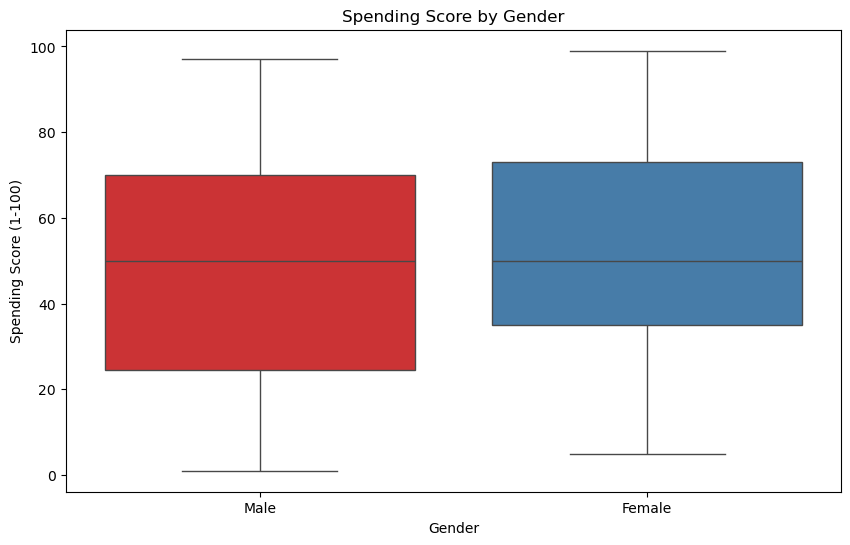

In [63]:
# Figure size
plt.figure(figsize=(10, 6))

#Plot type
sns.boxplot(data=df_plot, x='Genre', y='Spending Score (1-100)', palette='Set1')

# Plot details
plt.title('Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')

# Show plot
plt.show()

#### Average Annual Income by Age Group

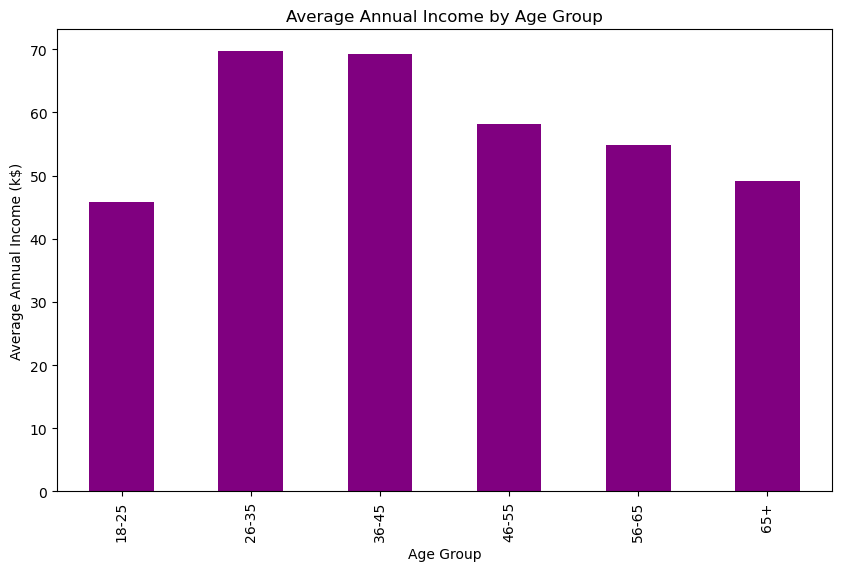

In [64]:
# Create the data
average_income_by_age = df_plot.groupby('Age Group')['Annual Income (k$)'].mean()

# define plot size
plt.figure(figsize=(10, 6))

# Define plot type
average_income_by_age.plot(kind='bar', color='purple')

# Detail plot
plt.title('Average Annual Income by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Annual Income (k$)')

# Show plot
plt.show()

### K-Means clustering

In [ ]:
# Select numerical features from the data
numerical_features = df.select_dtypes(include=np.number).columns

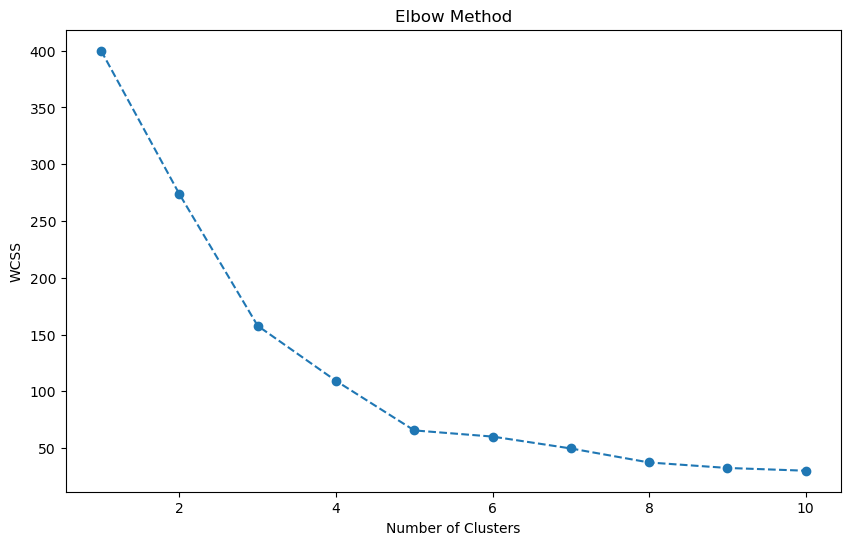

In [66]:
# Call method for scaling data 
scaler = StandardScaler()

# Subset for features we want to cluster on
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Fit data to scaler
X_scaled = scaler.fit_transform(X)

# Define clsuters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot size
plt.figure(figsize=(10, 6))

# Plot range
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')

# Detail the plot
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Fit KMeans on Annual Income and Spending Score
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Silhouette score on the same scaled features used for clustering
kmeans_score = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score: {kmeans_score:.2f}')

# Auto-assign business-friendly segment names from each cluster's mean income & spend
profile_temp = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

def assign_segment(income, spend):
    if income > 70 and spend > 65:
        return 'Premium\nShoppers'
    elif income > 70 and spend <= 65:
        return 'High Income\nLow Spenders'
    elif income <= 45 and spend > 65:
        return 'Budget\nEnthusiasts'
    elif income <= 45 and spend <= 45:
        return 'Low Income\nLow Spenders'
    else:
        return 'Average\nCustomers'

segment_map = {c: assign_segment(r['Annual Income (k$)'], r['Spending Score (1-100)'])
               for c, r in profile_temp.iterrows()}
df['Segment'] = df['Cluster'].map(segment_map)

print("\nCluster → Segment mapping:")
for c, name in segment_map.items():
    row = profile_temp.loc[c]
    print(f"  Cluster {c} | Income: {row['Annual Income (k$)']:.0f}k | Spend: {row['Spending Score (1-100)']:.0f} → {name.replace(chr(10), ' ')}")

#### Plot customer segmentation

In [ ]:
# Project centroids back to original feature scale for annotation placement
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
colours = sns.color_palette('viridis', 5)

plt.figure(figsize=(12, 7))

# Plot each segment separately so the legend shows segment names
for cluster_id in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster_id]
    label = segment_map[cluster_id].replace('\n', ' ')
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                color=colours[cluster_id], s=80, alpha=0.7, label=label)

# Annotate each centroid with the segment name
for i, (income, spend) in enumerate(centroids_original):
    plt.annotate(
        segment_map[i],
        xy=(income, spend),
        fontsize=8, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='grey', linewidth=0.8)
    )

plt.title('Customer Segments by Annual Income & Spending Score', fontsize=13, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [69]:
# Stats for graph 
stats_table = df.groupby('Cluster').describe().T
# Show
stats_table

Cluster                               0           1          2           3  \
Age                    count  81.000000   39.000000  22.000000   35.000000   
                       mean   42.716049   32.692308  25.272727   41.114286   
                       std    16.447822    3.728650   5.257030   11.341676   
                       min    18.000000   27.000000  18.000000   19.000000   
                       25%    27.000000   30.000000  21.250000   34.000000   
                       50%    46.000000   32.000000  23.500000   42.000000   
                       75%    54.000000   35.500000  29.750000   47.500000   
                       max    70.000000   40.000000  35.000000   59.000000   
Annual Income (k$)     count  81.000000   39.000000  22.000000   35.000000   
                       mean   55.296296   86.538462  25.727273   88.200000   
                       std     8.988109   16.312485   7.566731   16.399067   
                       min    39.000000   69.000000  15.000000   70.000000   
                       25%    48.000000   75.500000  19.250000   77.500000   
                       50%    54.000000   79.000000  24.500000   85.000000   
                       75%    62.000000   95.000000  32.250000   97.500000   
                       max    76.000000  137.000000  39.000000  137.000000   
Spending Score (1-100) count  81.000000   39.000000  22.000000   35.000000   
                       mean   49.518519   82.128205  79.363636   17.114286   
                       std     6.530909    9.364489  10.504174    9.952154   
                       min    34.000000   63.000000  61.000000    1.000000   
                       25%    44.000000   74.500000  73.000000   10.000000   
                       50%    50.000000   83.000000  77.000000   16.000000   
                       75%    55.000000   90.000000  85.750000   23.500000   
                       max    61.000000   97.000000  99.000000   39.000000   
Kmeans                 count  81.000000   39.000000  22.000000   35.000000   
                       mean    0.506173    3.153846   2.000000    3.000000   
                       std     1.173919    1.367642   0.000000    0.000000   
                       min     0.000000    1.000000   2.000000    3.000000   
                       25%     0.000000    1.000000   2.000000    3.000000   
                       50%     0.000000    4.000000   2.000000    3.000000   
                       75%     0.000000    4.000000   2.000000    3.000000   
                       max     4.000000    4.000000   2.000000    3.000000   

Cluster                               4  
Age                    count  23.000000  
                       mean   45.217391  
                       std    13.228607  
                       min    19.000000  
                       25%    35.500000  
                       50%    46.000000  
                       75%    53.500000  
                       max    67.000000  
Annual Income (k$)     count  23.000000  
                       mean   26.304348  
                       std     7.893811  
                       min    15.000000  
                       25%    19.500000  
                       50%    25.000000  
                       75%    33.000000  
                       max    39.000000  
Spending Score (1-100) count  23.000000  
                       mean   20.913043  
                       std    13.017167  
                       min     3.000000  
                       25%     9.500000  
                       50%    17.000000  
                       75%    33.500000  
                       max    40.000000  
Kmeans                 count  23.000000  
                       mean    0.086957  
                       std     0.417029  
                       min     0.000000  
                       25%     0.000000  
                       50%     0.000000  
                       75%     0.000000  
                       max     2.000000

In [ ]:
# Encode Genre using LabelEncoder
le = LabelEncoder()
df_hc = df.copy()
df_hc['Genre'] = le.fit_transform(df_hc['Genre'])

# Use raw features only
features_hc = df_hc[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
Z = linkage(features_hc, method='ward')

# Cut threshold — cutting here gives ~5 clusters to match K-Means
cut_threshold = 80

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    color_threshold=cut_threshold,
    above_threshold_color='grey'
)
plt.axhline(y=cut_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Cut at {cut_threshold}')
plt.title('Dendrogram with Cluster Cut')
plt.ylabel('Level of Dissimilarity')
plt.xlabel('Customer Groups')
plt.legend()
plt.show()

#### Clustered Heatmap

In [ ]:
# Normalise features to 0-1 so income doesn't dominate the colour scale
scaler_hc = MinMaxScaler()
features_scaled_hc = pd.DataFrame(
    scaler_hc.fit_transform(features_hc),
    columns=features_hc.columns,
    index=df_hc.index
)

# Map each customer row to its K-Means segment colour
cluster_palette = dict(zip(sorted(df['Cluster'].unique()), sns.color_palette('viridis', 5)))
row_colors = df['Cluster'].map(cluster_palette)

g = sns.clustermap(
    features_scaled_hc,
    method='ward',
    metric='euclidean',
    cmap='YlOrRd',
    figsize=(11, 13),
    yticklabels=False,
    col_cluster=False,
    row_colors=row_colors,
    cbar_pos=(1.05, 0.3, 0.03, 0.35),
    dendrogram_ratio=(0.2, 0.05)
)

# Segment colour legend
legend_patches = [mpatches.Patch(color=cluster_palette[c], label=segment_map[c].replace('\n', ' '))
                  for c in sorted(cluster_palette)]
g.ax_heatmap.legend(handles=legend_patches, title='Segment', loc='upper left',
                    bbox_to_anchor=(1.18, 1), fontsize=8, title_fontsize=9)

g.fig.suptitle('Clustered Heatmap: Customer Feature Profiles\n(colour bar = K-Means segment)',
               y=1.01, fontsize=12, fontweight='bold')
plt.show()

#### Cluster Profile Comparison

In [ ]:
# Mean feature values per segment
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Segment'] = profile.index.map(segment_map)
segment_labels = [s.replace('\n', '\n') for s in profile['Segment']]

features_to_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colours = sns.color_palette('viridis', len(profile))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, feature in zip(axes, features_to_plot):
    bars = ax.bar(range(len(profile)), profile[feature], color=colours, width=0.6)
    ax.set_xticks(range(len(profile)))
    ax.set_xticklabels(segment_labels, rotation=40, ha='right', fontsize=9)
    ax.set_title(f'Mean {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Value', fontsize=10)
    ax.set_ylim(0, profile[feature].max() * 1.18)
    for bar, val in zip(bars, profile[feature]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + profile[feature].max() * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Customer Segment Profile Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Segment Radar Chart

In [ ]:
# Normalise each feature to 0-1 so all axes are comparable
radar_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
radar_data = profile[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colours = sns.color_palette('viridis', len(radar_norm))

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colours[i], linewidth=2)
    ax.fill(angles, values, color=colours[i], alpha=0.12)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Segment Radar Chart\n(Features normalised to 0–1)', fontsize=13, fontweight='bold', pad=25)

# Legend
legend_patches = [mpatches.Patch(color=colours[i], label=segment_map[cluster_id].replace('\n', ' '))
                  for i, cluster_id in enumerate(radar_norm.index)]
ax.legend(handles=legend_patches, title='Segment', loc='upper right',
          bbox_to_anchor=(1.4, 1.1), fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()